In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.layers import Reshape
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("Imports loaded successfully.")

Imports loaded successfully.


In [2]:
def load_images(folder_path, image_size=(64,64)):
    data = []
    labels = []

    label = os.path.basename(folder_path)  # Extract the label from the folder name

    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        if os.path.isfile(img_path):  # Check if it is a file
            img = cv2.imread(img_path)
            if img is not None:  # Check if the image was read correctly
                img = cv2.resize(img, image_size)  # Resize images to a common size
                data.append(img)
                labels.append(label)

    return np.array(data), np.array(labels)

dataset_path = r"/kaggle/input/datasets/rupdasgupta/indian-uav/INDIAN_UAV"

# Load images for each type of chest X-ray
data_Healthy_Soyabean, labels_Healthy_Soyabean = load_images(os.path.join(dataset_path, 'Healthy_Soyabean'))
data_rust, labels_rust = load_images(os.path.join(dataset_path, 'rust'))
data_Soyabean_Mosaic, labels_Soyabean_Mosaic = load_images(os.path.join(dataset_path, 'Soyabean_Mosaic'))
data_Soyabean_Semilooper_Pest_Attack, labels_Soyabean_Semilooper_Pest_Attack = load_images(os.path.join(dataset_path, 'Soyabean Semilooper_Pest_Attack'))

print("Images loaded successfully.")

Images loaded successfully.


In [3]:
All_data = np.concatenate([
    data_Healthy_Soyabean,
    data_rust,
    data_Soyabean_Mosaic,
    data_Soyabean_Semilooper_Pest_Attack
])

All_labels = np.concatenate([
    labels_Healthy_Soyabean,
    labels_rust,
    labels_Soyabean_Mosaic,
    labels_Soyabean_Semilooper_Pest_Attack
])

print("Data concatenated successfully.")

Data concatenated successfully.


In [4]:
All_data_normalized = All_data / 255.0

print("Data normalized successfully.")

Data normalized successfully.


In [5]:
label_encoder = LabelEncoder()
all_labels_encoded = label_encoder.fit_transform(All_labels)
train_data, test_data, train_labels, test_labels = train_test_split(
    All_data_normalized, all_labels_encoded, test_size=0.20, random_state=42
)

print("Labels encoded and data split successfully.")

Labels encoded and data split successfully.


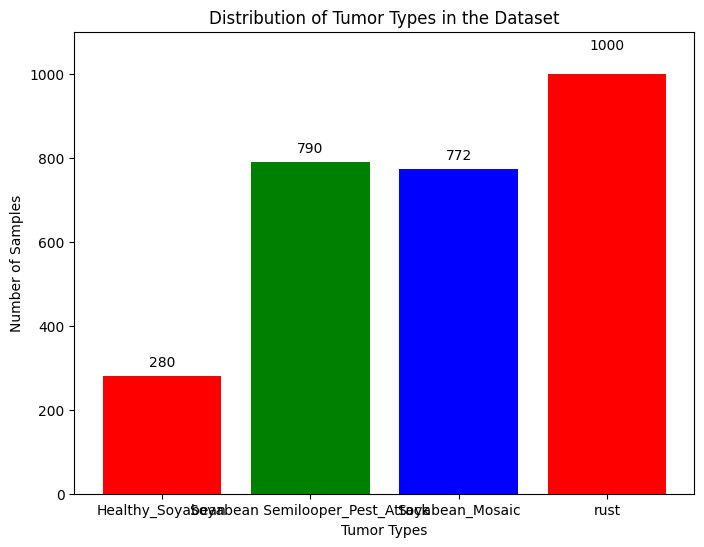

Data distribution plotted successfully.


In [6]:
unique_labels, label_counts = np.unique(All_labels, return_counts=True)
plt.figure(figsize=(8, 6))

plt.bar(unique_labels, label_counts, color=['red', 'green', 'blue'])
plt.xlabel('Tumor Types')
plt.ylabel('Number of Samples')
plt.title('Distribution of Tumor Types in the Dataset')

max_count = max(label_counts)
plt.ylim(0, max_count + 0.1 * max_count)

for i, count in enumerate(label_counts):
    plt.text(i, count + 0.05 * max_count, str(count), ha='center', va='bottom' if count > 0.9 * max_count else 'top')

plt.show()

print("Data distribution plotted successfully.")

In [12]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Number of classes
NUM_CLASSES = len(label_encoder.classes_)

# =========================
# Pretrained ResNet101
# =========================
base_model = ResNet101(
    weights="imagenet",
    include_top=False,
    input_shape=(64, 64, 3)
)

# Freeze pretrained layers
base_model.trainable = False

# =========================
# Build Model
# =========================
inputs = tf.keras.Input(shape=(64, 64, 3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

# =========================
# Compile
# =========================
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet101 (Functional)          │ (None, 2, 2, 2048)     │    42,658,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,666,372 (162.76 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 42,658,176 (162.73 MB)

In [8]:
history_finetune = model.fit(
    train_data,
    train_labels,
    validation_data=(test_data, test_labels),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4158 - loss: 1.2340 - val_accuracy: 0.4271 - val_loss: 1.2290
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.4267 - loss: 1.2350 - val_accuracy: 0.4868 - val_loss: 1.2238
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.4188 - loss: 1.2392 - val_accuracy: 0.4833 - val_loss: 1.2232
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.4215 - loss: 1.2321 - val_accuracy: 0.4130 - val_loss: 1.2202
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.4276 - loss: 1.2320 - val_accuracy: 0.4271 - val_loss: 1.2205
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.4232 - loss: 1.2269 - val_accuracy: 0.4429 - val_loss: 1.2182
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4452 - loss: 1.2149 - val_accuracy: 0.4394 - val_loss: 1.2122
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.4426 - loss: 1.2193 - val_accuracy: 0.4411 - v

In [13]:

# =========================
# Evaluate
# =========================
loss, accuracy = model.evaluate(
    test_data,
    test_labels,
    verbose=1
)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 191ms/step - accuracy: 0.0967 - loss: 1.8030
Test Loss: 1.8030
Test Accuracy: 0.0967


In [14]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

# Predict probabilities
y_pred_prob = model.predict(test_data)

# Convert probabilities to class indices
y_pred = np.argmax(y_pred_prob, axis=1)

# True labels
y_true = test_labels

# Accuracy
acc = accuracy_score(y_true, y_pred)

# Average (balanced) accuracy
avg_acc = balanced_accuracy_score(y_true, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Average Accuracy (Balanced Accuracy): {avg_acc:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)

18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 390ms/step
Accuracy: 0.0967
Average Accuracy (Balanced Accuracy): 0.2500

Classification Report:
                                 precision    recall  f1-score   support

               Healthy_Soyabean       0.10      1.00      0.18        55
Soyabean Semilooper_Pest_Attack       0.00      0.00      0.00       157
                Soyabean_Mosaic       0.00      0.00      0.00       156
                           rust       0.00      0.00      0.00       201

                       accuracy                           0.10       569
                      macro avg       0.02      0.25      0.04       569
                   weighted avg       0.01      0.10      0.02       569



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


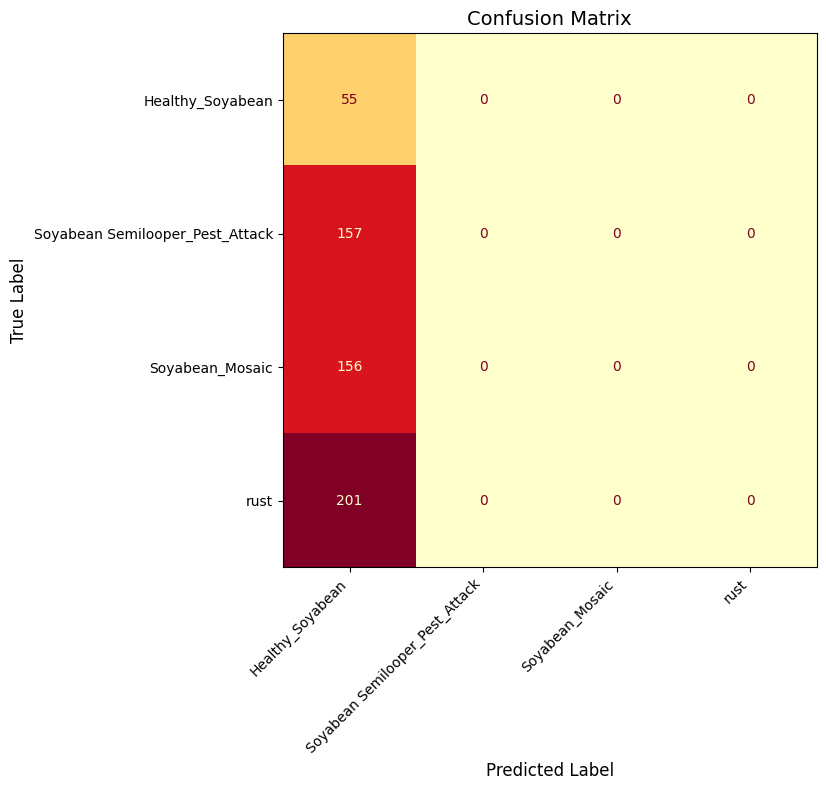

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred_prob = model.predict(test_data)
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion Matrix
cm = confusion_matrix(test_labels, y_pred)

# Larger figure
fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=ax,
    cmap="YlOrRd",
    values_format="d",
    colorbar=False
)

# Fix overlapping labels
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)

# Adjust layout automatically
plt.tight_layout()

plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


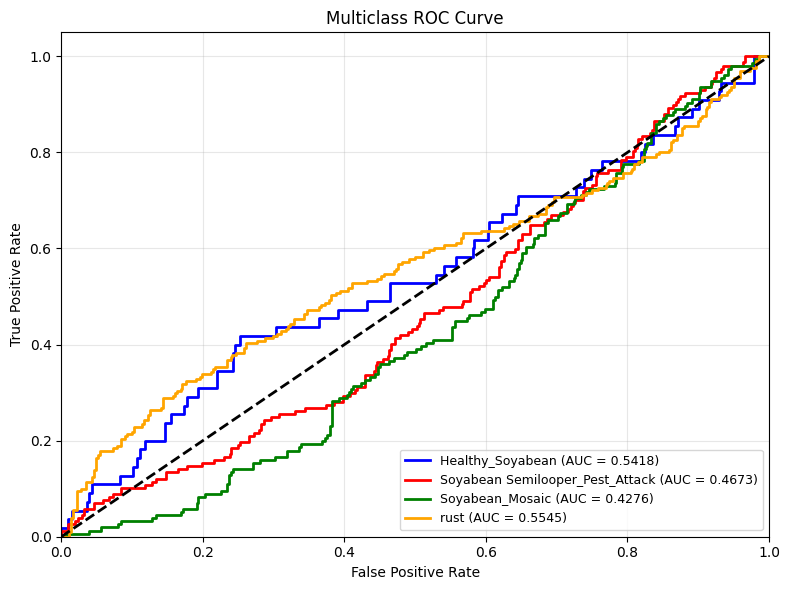

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Predict probabilities
y_score = model.predict(test_data)

# Number of classes
n_classes = len(label_encoder.classes_)

# Convert labels to one-hot format
y_test_bin = label_binarize(test_labels, classes=np.arange(n_classes))

# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(8,6))

colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f'{label_encoder.classes_[i]} (AUC = {roc_auc[i]:.4f})'
    )

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right', fontsize=9)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()